In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


Slope: 2.152450090744102
Intercept: -1.0435571687840337

Actual Power: [21 10 29]
Predicted Power: [20.48094374  9.71869328 29.0907441 ]

Mean Squared Error: 0.11892912078682315
R2 Score: 0.9980396298771402

Voltage: 16 V
Predicted Power: 33.3956442831216 W


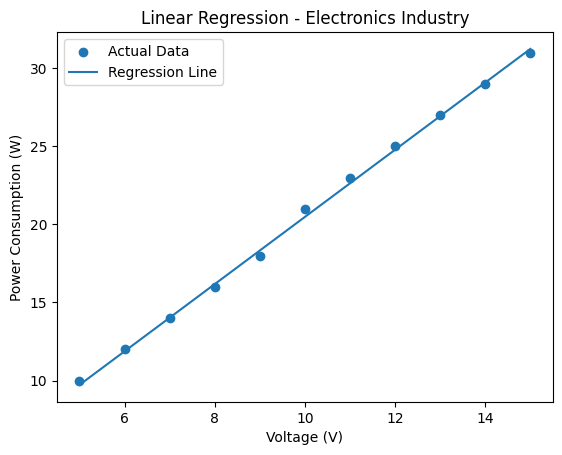

In [2]:
# 1. Sample electronics data
# Voltage (V)
X = np.array([
    5, 6, 7, 8, 9, 10,
    11, 12, 13, 14, 15
]).reshape(-1, 1)

# Power consumption (Watts)
y = np.array([
    10, 12, 14, 16, 18, 21,
    23, 25, 27, 29, 31
])

# 2. Split data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 3. Create Linear Regression model
model = LinearRegression()

# 4. Train the model
model.fit(X_train, y_train)

# 5. Make predictions
y_pred = model.predict(X_test)

# 6. Print model information
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

print("\nActual Power:", y_test)
print("Predicted Power:", y_pred)

# 7. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMean Squared Error:", mse)
print("R2 Score:", r2)

# 8. Predict power consumption for a new voltage
new_voltage = np.array([[16]])

predicted_power = model.predict(new_voltage)

print("\nVoltage:", new_voltage[0][0], "V")
print("Predicted Power:", predicted_power[0], "W")

# 9. Visualize the regression line
plt.scatter(X, y, label="Actual Data")
plt.plot(X, model.predict(X), label="Regression Line")

plt.xlabel("Voltage (V)")
plt.ylabel("Power Consumption (W)")
plt.title("Linear Regression - Electronics Industry")
plt.legend()
plt.show()

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

Dataset shape: (98, 25)
   Unnamed: 0     id  Gender      Customer Type  Age   Type of Travel  \
0           0  19556  Female     Loyal Customer   52  Business travel   
1           1  90035  Female     Loyal Customer   36  Business travel   
2           2  12360    Male  disloyal Customer   20  Business travel   
3           3  77959    Male     Loyal Customer   44  Business travel   
4           4  36875  Female     Loyal Customer   49  Business travel   

      Class  Flight Distance  Inflight wifi service  \
0       Eco              160                      5   
1  Business             2863                      1   
2       Eco              192                      2   
3  Business             3377                      0   
4       Eco             1182                      2   

   Departure/Arrival time convenient  ...  Inflight entertainment  \
0                                  4  ...                       5   
1                                  1  ...                       4   

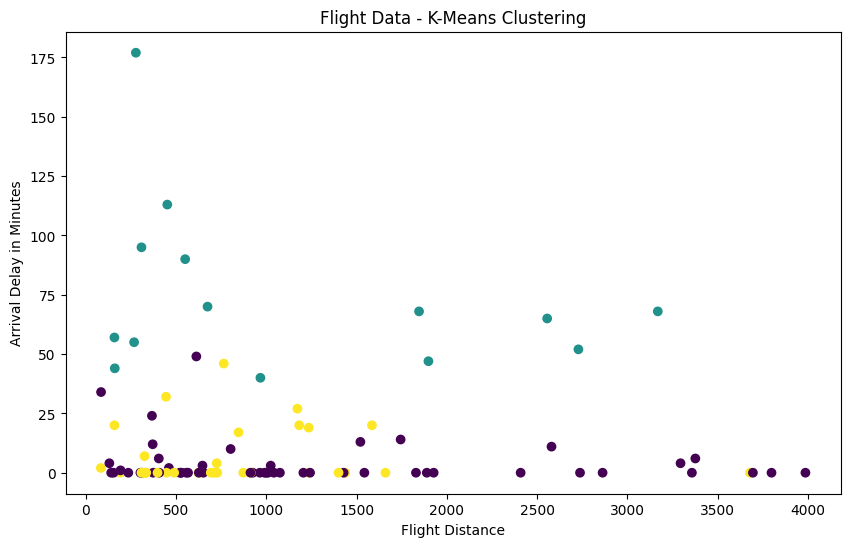

In [4]:
# 1. Load the dataset

df = pd.read_csv("FlightsData.csv")

print("Dataset shape:", df.shape)
print(df.head())


# 2. Select features for clustering

X = df[
[
"Age","Flight Distance","Inflight wifi service","Online boarding","Seat comfort","Departure Delay in Minutes",
"Arrival Delay in Minutes"
]
]

# 3. Handle missing values
X = X.fillna(X.mean())


# 4. Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 5. Create K-Means model
kmeans = KMeans(n_clusters=3,random_state=42,n_init=10)


# 6. Train the model
kmeans.fit(X_scaled)


# 7. Get cluster labels
df["cluster"] = kmeans.labels_


# 8. Display passengers with their clusters

print("\nPassengers and their clusters:")

print(
df[
["id","Age","Flight Distance","Inflight wifi service","Online boarding","Seat comfort","Departure Delay in Minutes",
"Arrival Delay in Minutes",
"cluster"
]
].to_string(index=False)
)


# 9. Count passengers in each cluster
print("\nNumber of passengers in each cluster:")

print(df["cluster"].value_counts().sort_index())


# 10. Visualize clusters

plt.figure(figsize=(10, 6))

plt.scatter(df["Flight Distance"],df["Arrival Delay in Minutes"],c=df["cluster"])

plt.xlabel("Flight Distance")
plt.ylabel("Arrival Delay in Minutes")
plt.title("Flight Data - K-Means Clustering")

plt.show()